Found 203 images belonging to 2 classes.
Found 50 images belonging to 2 classes.


c:\Users\shaky\anaconda3\envs\dl_env\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.6108 - loss: 1.3597 - val_accuracy: 0.7600 - val_loss: 0.5392
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.7931 - loss: 0.5192 - val_accuracy: 0.7400 - val_loss: 0.6105
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 858ms/step - accuracy: 0.8227 - loss: 0.4268 - val_accuracy: 0.7800 - val_loss: 0.5643
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 869ms/step - accuracy: 0.8818 - loss: 0.3571 - val_accuracy: 0.8000 - val_loss: 0.5607
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 766ms/step - accuracy: 0.8867 - loss: 0.2676 - val_accuracy: 0.8000 - val_loss: 0.4545
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 900ms/step - accuracy: 0.9458 - loss: 0.1845 - val_accuracy: 0.8600 - val_loss: 0.4261
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 851ms/step - accuracy: 0.9409 - loss: 0.1430 - val_accuracy: 0.8600 - val_loss: 0.3935
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 811ms/step - accuracy: 0.9655 - loss: 0.0995 - val_accuracy: 0.8000 - val_loss: 0.683

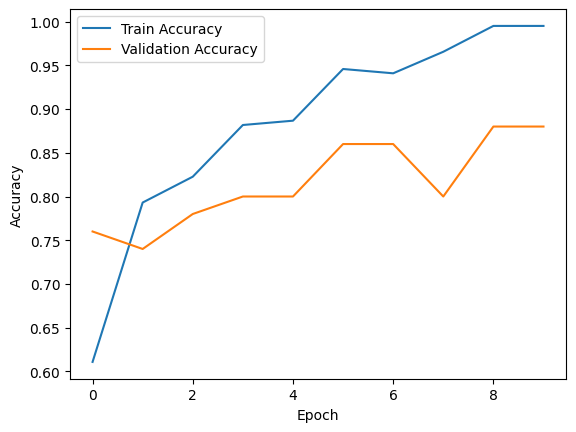

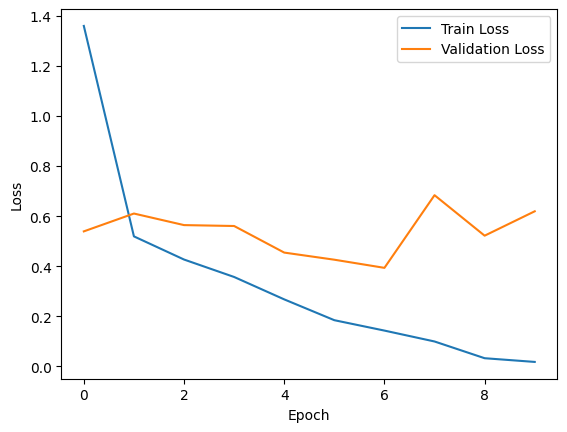

In [2]:
import tensorflow as tf          # Main deep learning framework used to build and train the neural network
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator        # Automatically loads and preprocesses images from folders
from tensorflow.keras import layers, models     #Used to build CNN layers and the neural network model

# Image size and batch size
img_size = 224
batch_size = 32

# Data preprocessing
train_datagen = ImageDataGenerator(
  rescale=1./255,      # [0, 1]
  validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
  "dataset/train",
  target_size=(img_size, img_size),
  batch_size=batch_size,
  class_mode='categorical',      # multi-Class
  subset='training'
)

val_generator = train_datagen.flow_from_directory(
  "dataset/train",
  target_size=(img_size, img_size),
  batch_size=batch_size,
  class_mode='categorical',
  subset='validation'
)

# CNN Model
model = models.Sequential()          # Layers are added one after another.

model.add(layers.Conv2D(32,(3,3),activation='relu',input_shape=(224,224,3)))
model.add(layers.MaxPooling2D(2,2))

model.add(layers.Conv2D(64,(3,3),activation='relu'))
model.add(layers.MaxPooling2D(2,2))

model.add(layers.Conv2D(128,(3,3),activation='relu'))
model.add(layers.MaxPooling2D(2,2))

model.add(layers.Flatten())

model.add(layers.Dense(128,activation='relu'))

model.add(layers.Dense(2,activation='softmax'))

# Compile model
model.compile(
  optimizer='adam',
  loss='categorical_crossentropy',
  metrics=['accuracy']
)

# Train model
history = model.fit(
  train_generator,
  epochs=10,
  validation_data=val_generator
)

# Evaluate model
loss, accuracy = model.evaluate(val_generator)

print("Validation Accuracy:", accuracy)

# Plot accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# Plot loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()